# Episode 3: RNN for Sequence Classification

**Goal**: Process sequences word-by-word with memory (hidden states)

---


## What is an RNN?

**Recurrent Neural Network** = Process sequence step-by-step, maintaining memory

```
Input:  word1 → word2 → word3 → ...
         ↓       ↓       ↓
Hidden: h1   → h2   → h3   → ... (memory)
```

### Key Concept: Hidden State

The **hidden state** is the RNN's memory:
- Carries information forward through the sequence
- Updated at each step based on current input + previous state
- Final state contains context from entire sequence

### For Classification:
Process entire sequence → Use final hidden state → Classify

In [1]:
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

---

## Part 1: Dataset & Preprocessing (Same as Before)

In [2]:
docs = [
    "Movies are fun for everyone.",
    "Watching movies is great fun.",
    "Enjoy a great movie today.",
    "Research is interesting and important.",
    "Learning math is very important.",
    "Science discovery is interesting.",
    "Rock is great to listen to.",
    "Listen to music for fun.",
    "Music is fun for everyone.",
    "Listen to folk music!"
]

labels = [1, 1, 1, 3, 3, 3, 2, 2, 2, 2]
class_names = ["Cinema", "Music", "Science"]
num_classes = 3

# Tokenization and vocabulary
def tokenize(text):
    return re.findall(r"\w+", text.lower())

def get_vocabulary(texts):
    tokens = {token for text in texts for token in tokenize(text)}
    return {word: idx for idx, word in enumerate(sorted(tokens))}

vocabulary = get_vocabulary(docs)
vocab_size = len(vocabulary)

# Convert to indices
def doc_to_indices(doc, vocabulary):
    tokens = tokenize(doc)
    return [vocabulary[token] for token in tokens if token in vocabulary]

doc_indices = [doc_to_indices(doc, vocabulary) for doc in docs]
labels_tensor = torch.tensor(labels, dtype=torch.long) - 1

print(f"Vocabulary size: {vocab_size}")
print(f"Example doc: {docs[0]}")
print(f"As indices: {doc_indices[0]}")

Vocabulary size: 26
Example doc: Movies are fun for everyone.
As indices: [17, 2, 8, 7, 5]


---

## Part 2: RNN Classifier

### Architecture:

```
Word Indices → Embeddings → RNN (sequential processing) → Final Hidden State → Classifier
```

### How RNN Works:

For each word in sequence:
1. Look up embedding
2. Combine with previous hidden state
3. Compute new hidden state
4. Repeat

**Final hidden state** contains information from entire sequence → use for classification

In [3]:
embedding_dim = 10
hidden_dim = 20
output_dim = num_classes

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Embedding layer (same as Episode 2)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # RNN layer - processes sequences
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        
        # Classification layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        """
        x: [batch_size, seq_len] - word indices
        """
        # Embed words: [batch_size, seq_len, embedding_dim]
        embeds = self.embedding(x)
        
        # RNN processes sequence
        # output: [batch_size, seq_len, hidden_dim] (hidden states at each step)
        # hidden: [1, batch_size, hidden_dim] (final hidden state)
        output, hidden = self.rnn(embeds)
        
        # Use final hidden state for classification
        # Take last output (equivalent to final hidden state)
        final_state = output[:, -1, :]  # [batch_size, hidden_dim]
        
        # Classify
        logits = self.fc(final_state)  # [batch_size, output_dim]
        
        return logits

model = RNNClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

RNNClassifier(
  (embedding): Embedding(26, 10)
  (rnn): RNN(10, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=3, bias=True)
)

Total parameters: 963


### 🔍 Understanding RNN Parameters

The RNN has learned weight matrices for:
- **Input to hidden**: How to process current word
- **Hidden to hidden**: How to combine with previous memory
- **Bias terms**: Learned offsets

All these are learned through backpropagation!

---

## Part 3: Training

Same process as before, but now RNN processes sequences properly!

In [4]:
# Pad sequences to same length for batch processing
def pad_sequences(sequences, pad_value=0):
    max_len = max(len(seq) for seq in sequences)
    padded = [seq + [pad_value] * (max_len - len(seq)) for seq in sequences]
    return torch.tensor(padded, dtype=torch.long)

# Create batched input
input_tensor = pad_sequences(doc_indices)

print(f"Input tensor shape: {input_tensor.shape}")
print(f"  [num_docs={len(docs)}, max_seq_len={input_tensor.shape[1]}]")

Input tensor shape: torch.Size([10, 6])
  [num_docs=10, max_seq_len=6]


In [5]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 500
losses = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(input_tensor)
    loss = criterion(outputs, labels_tensor)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("\nTraining complete :-)")

Epoch [100/500], Loss: 0.0008
Epoch [200/500], Loss: 0.0004
Epoch [300/500], Loss: 0.0002
Epoch [400/500], Loss: 0.0002
Epoch [500/500], Loss: 0.0001

Training complete :-)


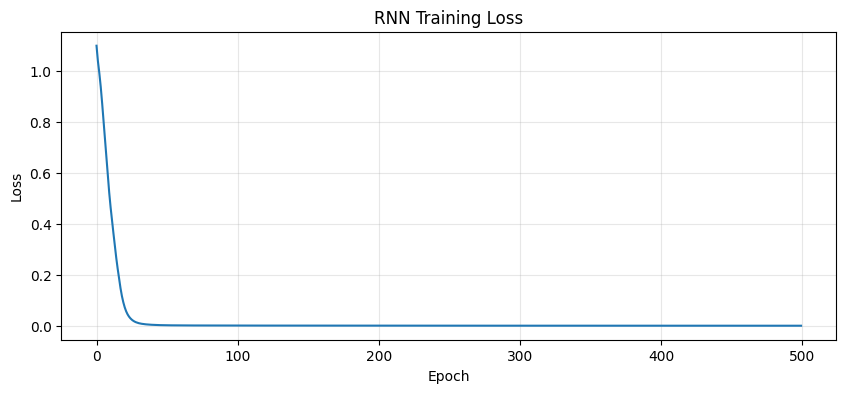

In [6]:
# Visualize training
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

---

## Part 4: Evaluation

In [7]:
# Evaluate
model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    
    print("Training Set Performance:")
    print("="*60)
    correct = 0
    
    for i, doc in enumerate(docs):
        true_label = labels_tensor[i].item()
        pred_label = predicted[i].item()
        correct += (true_label == pred_label)
        
        status = "1" if true_label == pred_label else "X"
        print(f"{status} {doc}")
        print(f"  True: {class_names[true_label]}, Predicted: {class_names[pred_label]}")
    
    accuracy = 100 * correct / len(docs)
    print(f"\nAccuracy: {accuracy:.1f}% ({correct}/{len(docs)})")

Training Set Performance:
1 Movies are fun for everyone.
  True: Cinema, Predicted: Cinema
1 Watching movies is great fun.
  True: Cinema, Predicted: Cinema
1 Enjoy a great movie today.
  True: Cinema, Predicted: Cinema
1 Research is interesting and important.
  True: Science, Predicted: Science
1 Learning math is very important.
  True: Science, Predicted: Science
1 Science discovery is interesting.
  True: Science, Predicted: Science
1 Rock is great to listen to.
  True: Music, Predicted: Music
1 Listen to music for fun.
  True: Music, Predicted: Music
1 Music is fun for everyone.
  True: Music, Predicted: Music
1 Listen to folk music!
  True: Music, Predicted: Music

Accuracy: 100.0% (10/10)


---

## Part 5: Test on New Documents

In [8]:
new_docs = [
    "Listening to rock music is fun.",
    "I love science very much.",
    "Films are my passion"
]

# Convert to indices and pad
new_indices = [doc_to_indices(doc, vocabulary) for doc in new_docs]
new_input = pad_sequences(new_indices)

print("Test Document Predictions:")
print("="*60)

with torch.no_grad():
    outputs = model(new_input)
    probabilities = torch.softmax(outputs, dim=1)
    predicted = torch.argmax(outputs, dim=1)
    
    for i, doc in enumerate(new_docs):
        pred_class = class_names[predicted[i].item()]
        probs = probabilities[i]
        
        print(f"\nDocument: \"{doc}\"")
        print(f"Prediction: {pred_class}")
        print(f"Confidence:")
        for j, class_name in enumerate(class_names):
            print(f"  {class_name}: {probs[j].item():.2%}")

Test Document Predictions:

Document: "Listening to rock music is fun."
Prediction: Music
Confidence:
  Cinema: 0.06%
  Music: 99.94%
  Science: 0.00%

Document: "I love science very much."
Prediction: Science
Confidence:
  Cinema: 0.01%
  Music: 0.01%
  Science: 99.99%

Document: "Films are my passion"
Prediction: Science
Confidence:
  Cinema: 0.01%
  Music: 0.01%
  Science: 99.99%


---

## Part 6: Visualizing RNN Hidden States

Let's peek inside the RNN and see how the hidden state evolves as it processes a sequence!

Document: Movies are fun for everyone.
Tokens: ['movies', 'are', 'fun', 'for', 'everyone']


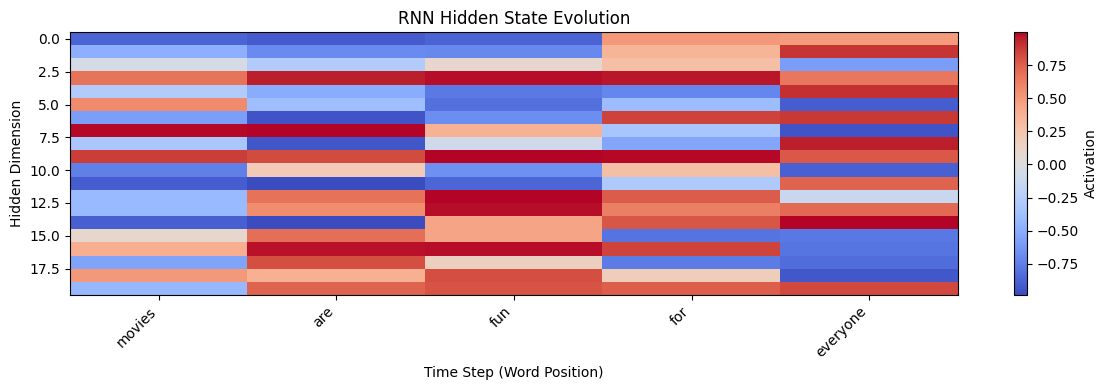

Observation:
Each column shows the hidden state after processing that word.
The hidden state changes as the RNN accumulates information from the sequence!


In [9]:
# Extract hidden states for a sample document
sample_doc = "Movies are fun for everyone."
sample_indices = doc_to_indices(sample_doc, vocabulary)
sample_tokens = tokenize(sample_doc)

print(f"Document: {sample_doc}")
print(f"Tokens: {sample_tokens}")

# Process through RNN and capture hidden states at each step
model.eval()
with torch.no_grad():
    x = torch.tensor([sample_indices], dtype=torch.long)
    embeds = model.embedding(x)
    output, hidden = model.rnn(embeds)
    
    # output contains hidden state at each time step
    hidden_states = output[0].numpy()  # [seq_len, hidden_dim]

# Visualize hidden state evolution
plt.figure(figsize=(12, 4))
plt.imshow(hidden_states.T, aspect='auto', cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Activation')
plt.xlabel('Time Step (Word Position)')
plt.ylabel('Hidden Dimension')
plt.title('RNN Hidden State Evolution')
plt.xticks(range(len(sample_tokens)), sample_tokens, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Observation:")
print("Each column shows the hidden state after processing that word.")
print("The hidden state changes as the RNN accumulates information from the sequence!")

---

## Episode 3 Summary

### What We Learned:

**RNNs process sequences step-by-step**: Word-by-word with memory  
**Hidden state = memory**: Carries context forward through sequence  
**Word order matters**: Unlike average pooling, RNNs capture sequential structure  
**Final hidden state**: Contains information from entire sequence → used for classification  

### Key Insights:

1. **Sequential processing**: RNN updates its memory at each step
2. **Context accumulation**: Later words are processed with context from earlier words
3. **Still classification**: Using final state for document-level prediction

### Comparison: Episode 2 vs. Episode 3

| Feature | Embeddings + Pooling | RNN |
|---------|---------------------|-----|
| Word order | Lost (average) | Preserved |
| Processing | Parallel | Sequential |
| Memory | None | Hidden state |
| Context | None | Accumulated |

